In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('blood_pressure_global_dataset.csv')
df=pd.read_csv('country_bp_summary.csv')

In [4]:
df.head(5)

,Country,WHO_Region,Income_Level,Sample_Size,Mean_Age,Mean_SBP,Mean_DBP,Std_SBP,Std_DBP,Mean_MAP,Hypertension_Rate_pct,Awareness_Rate_pct,Treatment_Rate_pct,Control_Rate_pct,Country_HTN_Prevalence
0,Cameroon,Africa,Lower-Middle Income,95,45.11,131.01,76.32,22.57,13.01,94.55,64.0,33.0,15.0,2.0,43
1,Japan,Western Pacific,High Income,92,43.12,130.92,78.33,22.29,12.33,95.87,63.0,30.0,14.0,3.0,48
2,Portugal,Europe,High Income,92,44.51,130.59,77.02,22.87,12.93,94.88,59.0,18.0,9.0,2.0,29
3,Qatar,Eastern Mediterranean,High Income,84,39.50,130.50,75.61,25.26,11.84,93.91,50.0,19.0,6.0,1.0,33
4,Indonesia,South-East Asia,Upper-Middle Income,94,42.95,130.06,75.03,22.22,12.59,93.37,59.0,24.0,6.0,1.0,34


In [5]:
df.shape

(86, 15)

In [6]:
df.columns

Index(['Country', 'WHO_Region', 'Income_Level', 'Sample_Size', 'Mean_Age',
       'Mean_SBP', 'Mean_DBP', 'Std_SBP', 'Std_DBP', 'Mean_MAP',
       'Hypertension_Rate_pct', 'Awareness_Rate_pct', 'Treatment_Rate_pct',
       'Control_Rate_pct', 'Country_HTN_Prevalence'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 86 non-null     object 
 1   WHO_Region              86 non-null     object 
 2   Income_Level            86 non-null     object 
 3   Sample_Size             86 non-null     int64  
 4   Mean_Age                86 non-null     float64
 5   Mean_SBP                86 non-null     float64
 6   Mean_DBP                86 non-null     float64
 7   Std_SBP                 86 non-null     float64
 8   Std_DBP                 86 non-null     float64
 9   Mean_MAP                86 non-null     float64
 10  Hypertension_Rate_pct   86 non-null     float64
 11  Awareness_Rate_pct      86 non-null     float64
 12  Treatment_Rate_pct      86 non-null     float64
 13  Control_Rate_pct        86 non-null     float64
 14  Country_HTN_Prevalence  86 non-null     int6

In [8]:
df.isnull().sum()

Country                   0
WHO_Region                0
Income_Level              0
Sample_Size               0
Mean_Age                  0
Mean_SBP                  0
Mean_DBP                  0
Std_SBP                   0
Std_DBP                   0
Mean_MAP                  0
Hypertension_Rate_pct     0
Awareness_Rate_pct        0
Treatment_Rate_pct        0
Control_Rate_pct          0
Country_HTN_Prevalence    0
dtype: int64

In [9]:
df.columns= df.columns.str.lower().str.replace(' ','_')

In [10]:
df.columns

Index(['country', 'who_region', 'income_level', 'sample_size', 'mean_age',
       'mean_sbp', 'mean_dbp', 'std_sbp', 'std_dbp', 'mean_map',
       'hypertension_rate_pct', 'awareness_rate_pct', 'treatment_rate_pct',
       'control_rate_pct', 'country_htn_prevalence'],
      dtype='object')

In [11]:
df.describe()

,sample_size,mean_age,mean_sbp,mean_dbp,std_sbp,std_dbp,mean_map,hypertension_rate_pct,awareness_rate_pct,treatment_rate_pct,control_rate_pct,country_htn_prevalence
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,93.023256,39.968256,125.731163,75.809419,22.836047,13.063488,92.449535,54.348837,23.255814,9.790698,2.081395,34.558140
std,9.331763,2.305551,2.436700,1.208548,1.911651,0.862094,1.414858,5.114610,5.154521,3.633557,1.709593,5.971707
min,73.000000,33.490000,120.730000,72.700000,17.920000,10.520000,88.920000,41.000000,10.000000,1.000000,0.000000,24.000000
25%,86.000000,38.307500,124.192500,74.997500,21.772500,12.547500,91.332500,50.250000,19.000000,7.000000,1.000000,30.000000
50%,92.500000,39.710000,125.590000,75.825000,22.565000,12.990000,92.630000,54.500000,24.000000,9.000000,2.000000,35.000000
75%,100.000000,41.817500,127.485000,76.685000,23.787500,13.610000,93.442500,58.000000,27.000000,12.000000,3.000000,38.000000
max,120.000000,45.420000,131.010000,78.330000,27.730000,15.500000,95.870000,65.000000,33.000000,18.000000,7.000000,48.000000


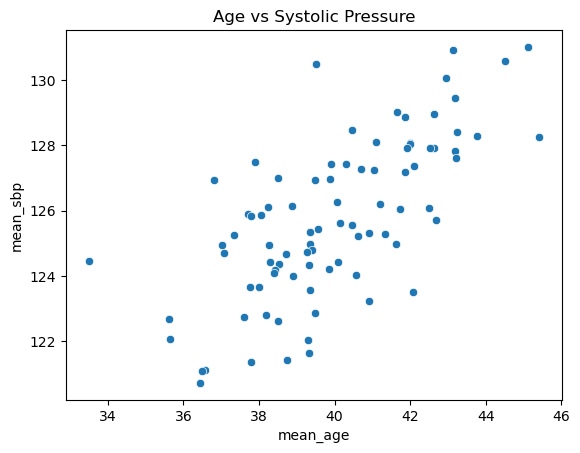

In [12]:
sns.scatterplot(data=df,x='mean_age',y='mean_sbp')
plt.title("Age vs Systolic Pressure")
plt.show()

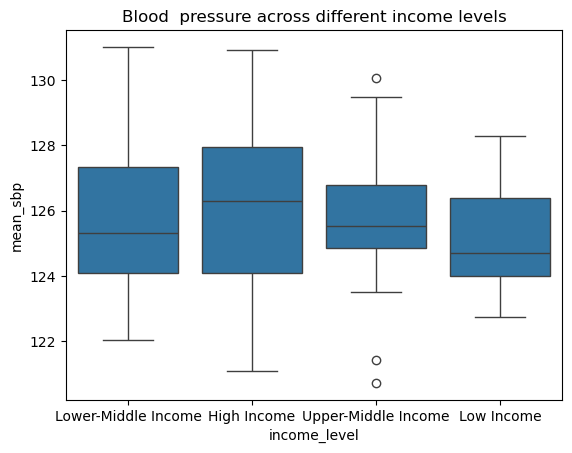

In [13]:
sns.boxplot(data=df,x='income_level',y='mean_sbp')
plt.title("Blood  pressure across different income levels")
plt.show()

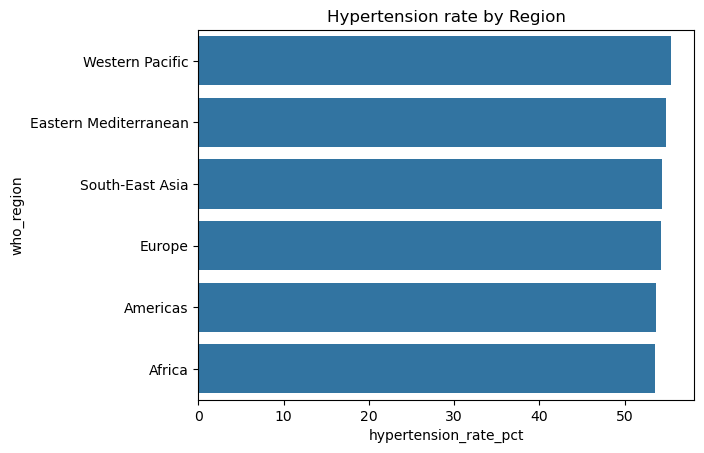

In [14]:
region_htn= df.groupby('who_region')['hypertension_rate_pct'].mean().sort_values(ascending= False)

sns.barplot(x=region_htn,y=region_htn.index)
plt.title("Hypertension rate by Region")
plt.show()

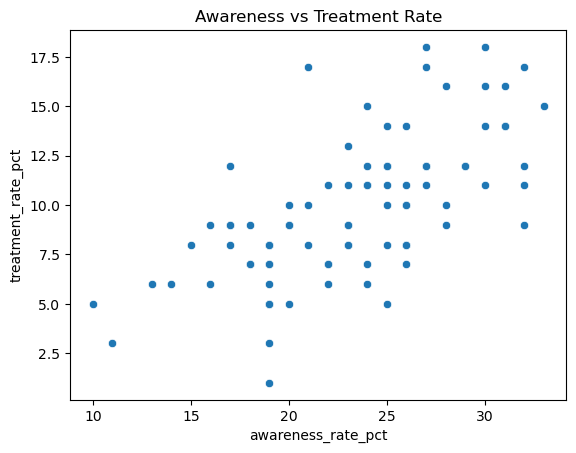

In [15]:
sns.scatterplot(data=df,x='awareness_rate_pct',y='treatment_rate_pct')
plt.title("Awareness vs Treatment Rate")
plt.show()

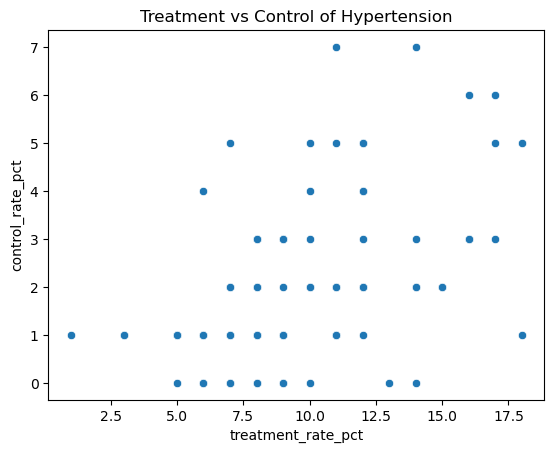

In [16]:
sns.scatterplot(data=df, x='treatment_rate_pct', y='control_rate_pct')
plt.title('Treatment vs Control of Hypertension')
plt.show()

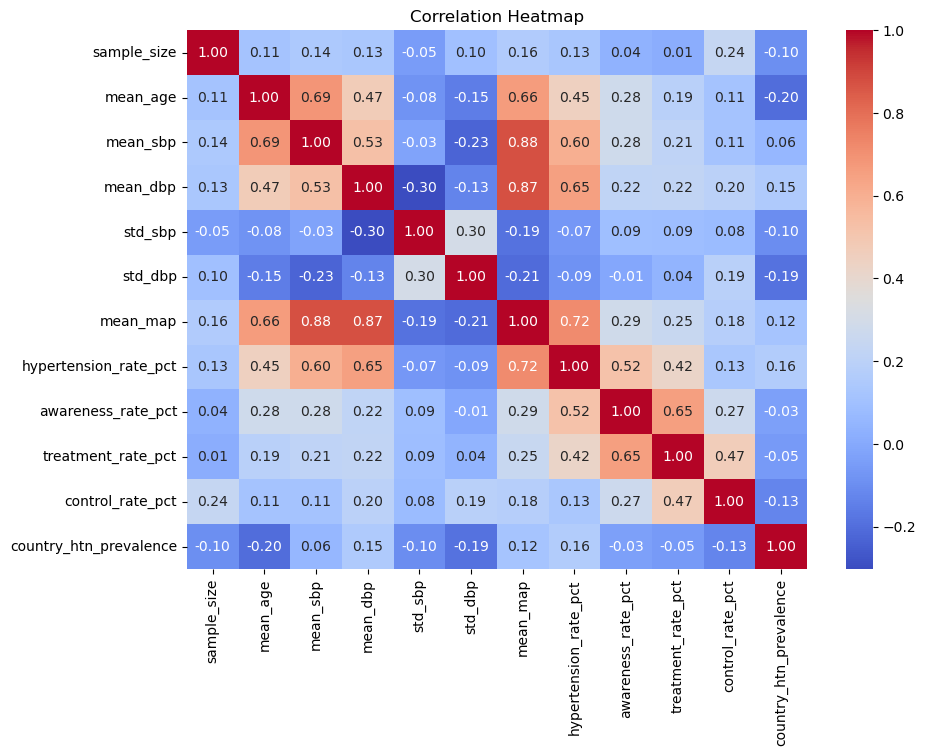

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

<Figure size 800x600 with 0 Axes>

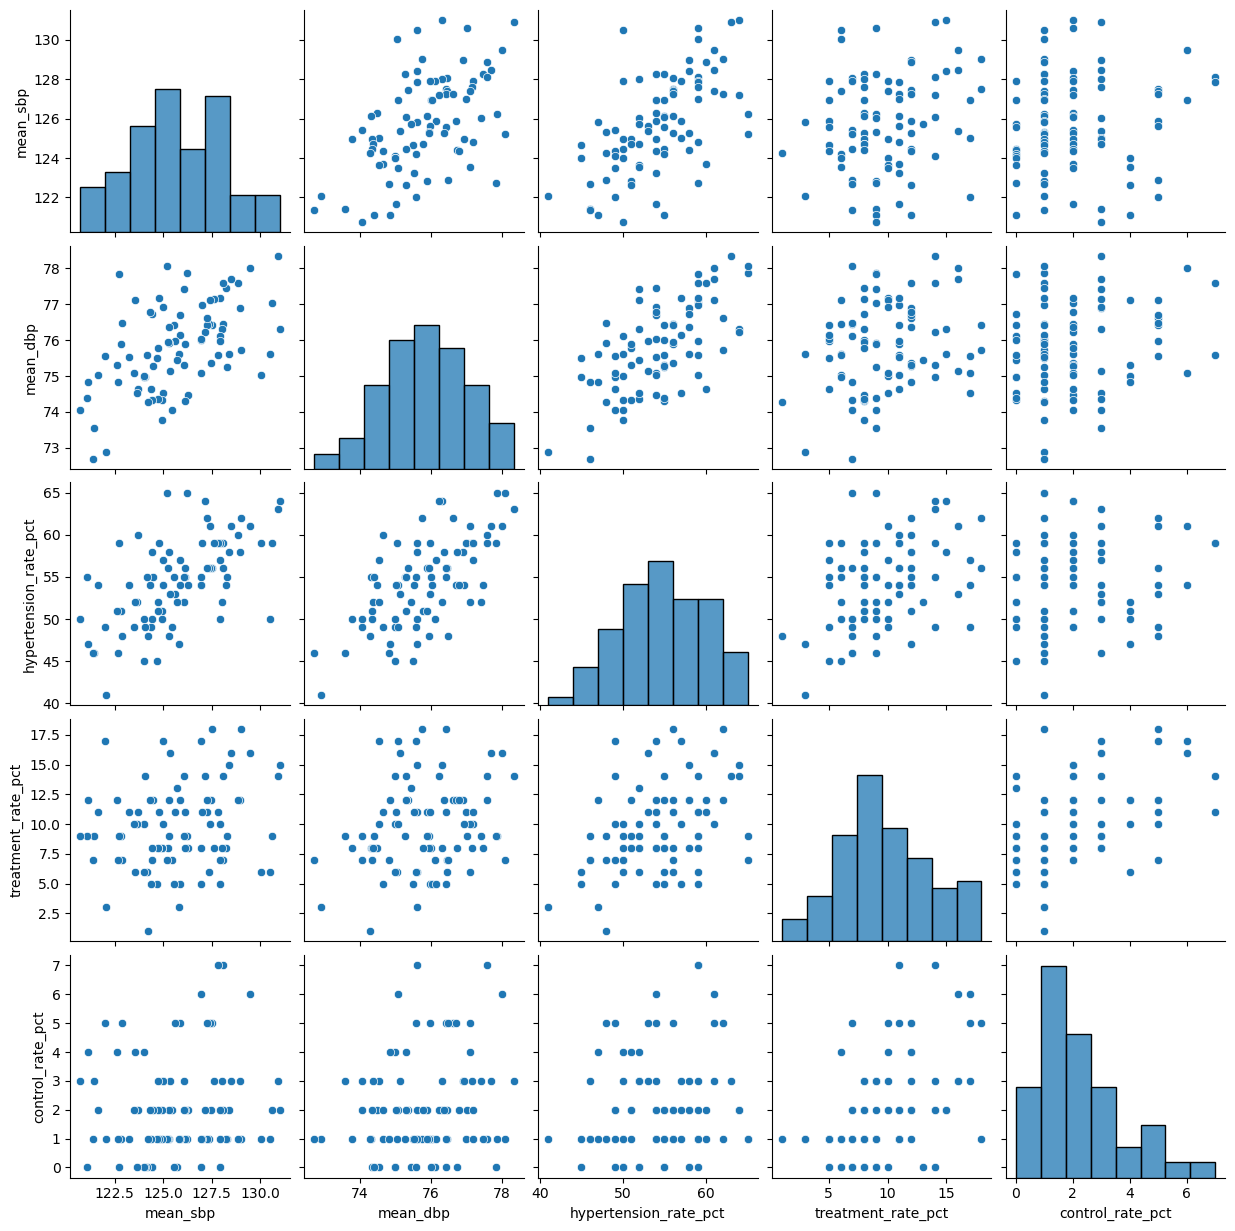

In [21]:
selected_cols= ['mean_sbp','mean_dbp','hypertension_rate_pct','treatment_rate_pct','control_rate_pct']

plt.figure(figsize=(8,6))
sns.pairplot(df[selected_cols])
plt.show()

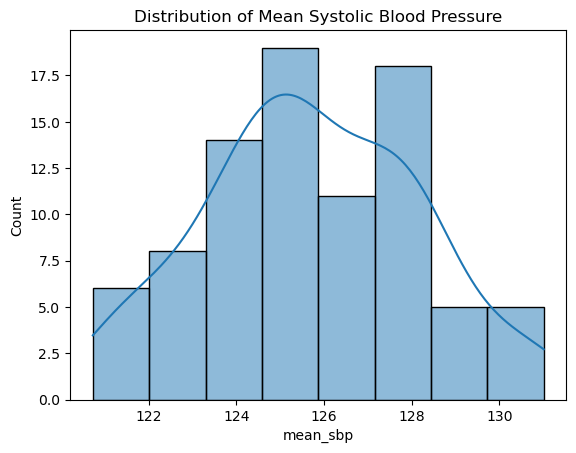

In [24]:
sns.histplot(df['mean_sbp'],kde=True)
plt.title('Distribution of Mean Systolic Blood Pressure')
plt.show()

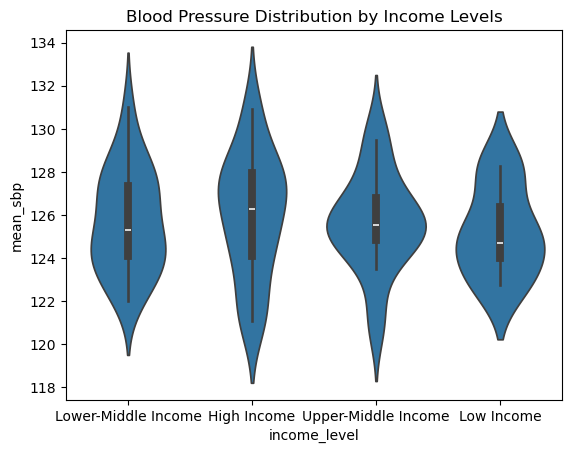

In [27]:
sns.violinplot(data=df,x='income_level',y='mean_sbp')
plt.title("Blood Pressure Distribution by Income Levels")
plt.show()

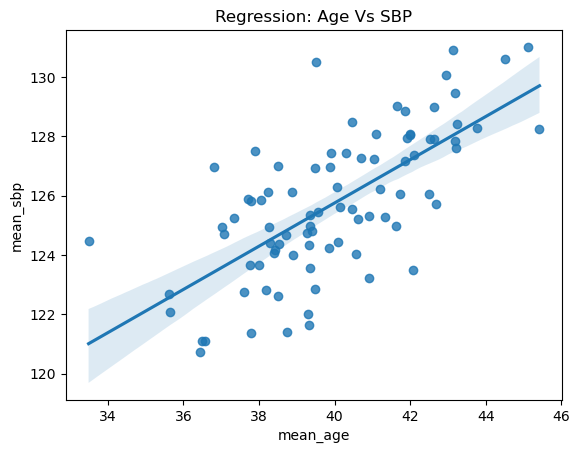

In [29]:
sns.regplot(data=df,x='mean_age',y='mean_sbp')
plt.title("Regression: Age Vs SBP")
plt.show()